# Liam Gines, Tyrese Gill

# Churn Prediction
Shortcut to run all blocks: ESC, CTRL + A, SHIFT + ENTER

## Imports

In [7]:
# Working with data
import pandas as pd
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing: encoding, scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler, Normalizer

# For imbalanced datasets
from sklearn.utils import resample
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, ADASYN

# Testing, model tuning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Selected models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, f1_score

## Dataset Info

In [8]:
# Add data to a data frame
CSV_FILE = "Churn_Modelling.csv"
data_frame = pd.read_csv(CSV_FILE)

# Identifying attributes
TARGET = "Exited"
UNNECESSARY_FEATURES = ["RowNumber", "CustomerId", "Surname"]
NOMINAL_FEATURES = ["Surname", "Geography", "Gender"]

# Defining nominal features that will be kept: Geography, Gender
SELECTED_NOMINAL_FEATURES = list(set(NOMINAL_FEATURES) - set(UNNECESSARY_FEATURES))

RANDOM_STATE = 123
NUM_ROWS_TO_DISPLAY = 3

data_frame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Dataset Stats

In [9]:
data_frame.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## No Values are Missing

In [10]:
data_frame.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Display Class Imbalance of Target

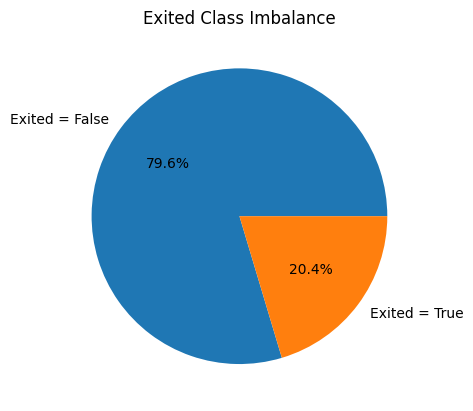

In [11]:
# https://wellsr.com/python/upsampling-and-downsampling-imbalanced-data-in-python/
def frame_target_imbalance(df):
    df.groupby(TARGET).size().plot(kind="pie", y=TARGET, title=f"{TARGET} Class Imbalance", labels=[f"{TARGET} = False", f"{TARGET} = True"], autopct="%1.1f%%")

frame_target_imbalance(data_frame)

## TEMPORARILY Label Encode Selected Nominal Features
This is temporarily done so these features will be shown on the box plot. Using the dataset with Nominal Features being Label Encoded is bad practice because a model might think there is some order to the Nominal Features when there isn't one in reality. We will transform the data frame to use One-hot encoding before training and testing later on. For more information, see https://stackoverflow.com/questions/36631163/what-are-the-pros-and-cons-between-get-dummies-pandas-and-onehotencoder-sciki. Finally, note that One-hot encoding led to an improvement in the Decision Tree's performance later on.

In [12]:
label_encoder = LabelEncoder()
for nominal_feature in SELECTED_NOMINAL_FEATURES:
    current_feature_values = data_frame[nominal_feature]
    label_encoder.fit(current_feature_values)
    data_frame[nominal_feature] = label_encoder.transform(current_feature_values)

data_frame.head(NUM_ROWS_TO_DISPLAY)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Show Feature Distributions

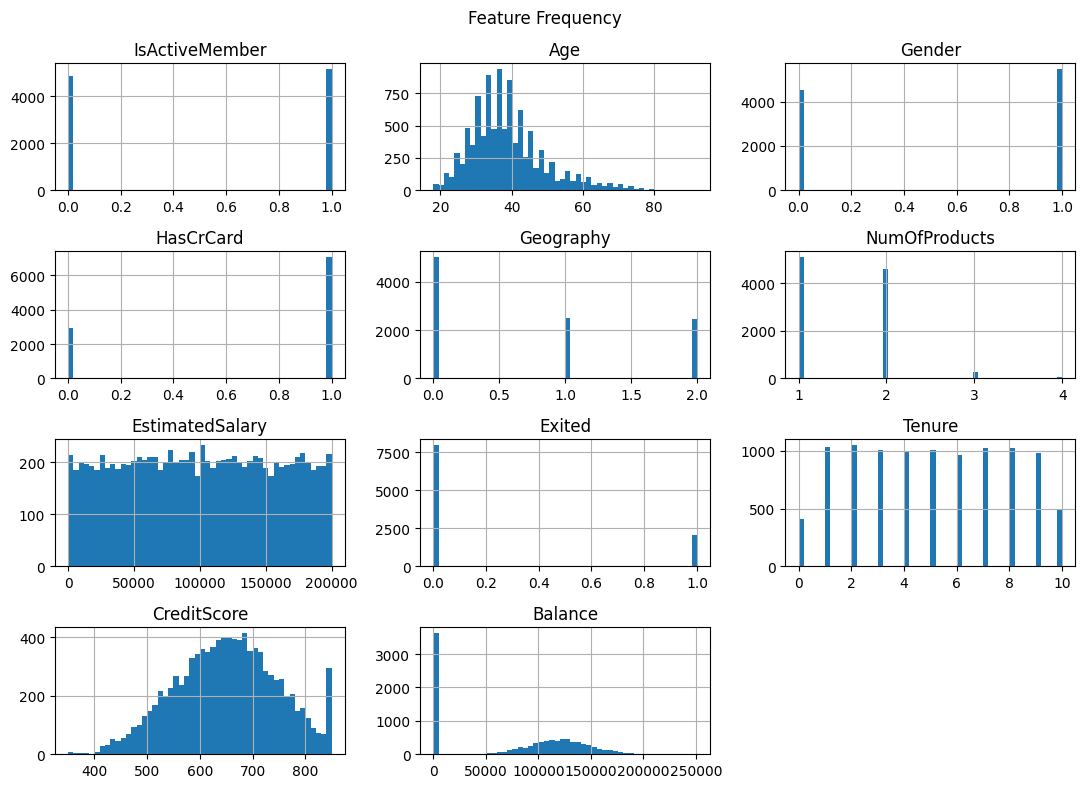

In [15]:
FEATURED_DISTRIBUTIONS = list(set(data_frame.columns) - set(UNNECESSARY_FEATURES))
data_frame[FEATURED_DISTRIBUTIONS].hist(figsize=(11, 8), bins=50)
plt.suptitle("Feature Frequency")
plt.tight_layout()
plt.show()

## Remove Unnecessary Features from the Dataset

In [16]:
data_frame = data_frame.drop(columns=UNNECESSARY_FEATURES)
data_frame.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Show Unscaled Features (Plot includes Target "Exited")

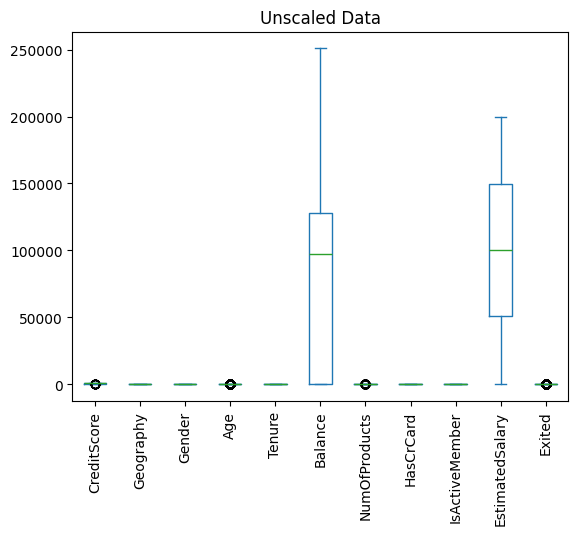

In [17]:
def frame_box_plot(df, title):
    df.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

frame_box_plot(data_frame, "Unscaled Data")

## Show Scaled Features (Plot includes Target "Exited")

**NOTE**: Do not use "data_frame_scaled" to produce training and test sets. This is because we do not want to scale the Target "Exited". We want to keep the Target as 0s and 1s. Scaling the Target will lead to problems later on, as it will instead label the values 0 and 1 as -1 and 1 instead. The box plot below is purely for showing the scaled features only.

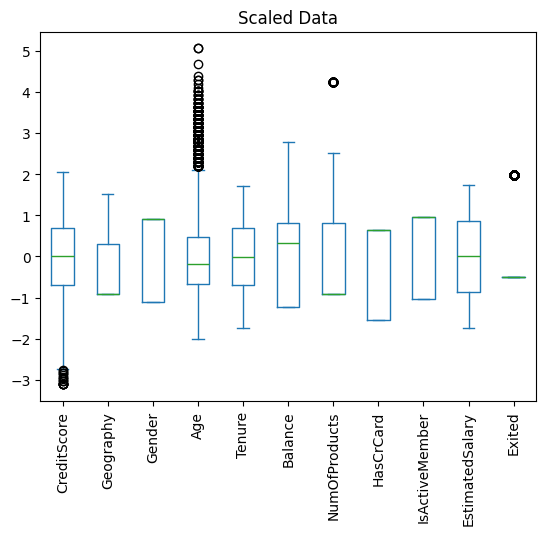

In [18]:
def get_scaled_frame(df):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    return pd.DataFrame(data=df_scaled, columns=df.columns)

data_frame_scaled = get_scaled_frame(data_frame)
frame_box_plot(data_frame_scaled, "Scaled Data")

## Choosing Outliers for Removal in Training
The outliers in "NumOfProducts" seemed like it might cause issues for our models and it actually did in practice.
Age seems to capture something important, so we have left its outliers in. You can see the directly proportional relationship between churning customers and age in the Correlation Matrix.

Below are some other combinations of outliers that we tried excluding from our training sets.

In [72]:
# OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts", "Age"]
# OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts", "CreditScore"]
# OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts", "CreditScore", "Age"]

OUTLIERS_TO_REMOVE_IN_TRAINING = ["NumOfProducts"]

## Show Normalized Features (Plot includes Target "Exited")
**NOTE**: Do not use "data_frame_normalized" to produce training and test sets because we do not want to normalize the Target either. This is only done to illustrate the effect of normalization.

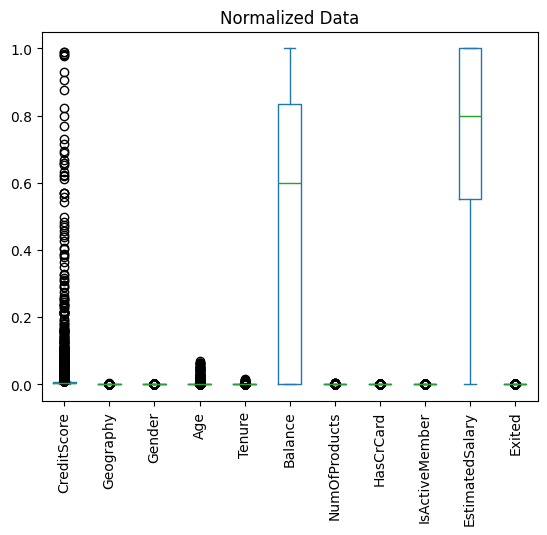

In [20]:
def get_normalized_frame(df):
    normalizer = Normalizer()
    df_normalized = normalizer.fit_transform(df)
    return pd.DataFrame(data=df_normalized, columns=df.columns)

data_frame_normalized = get_normalized_frame(data_frame)
frame_box_plot(data_frame_normalized, "Normalized Data")

## Applying One-Hot Encoding to Selected Nominal Features

In [22]:
data_frame = pd.get_dummies(data_frame, columns=SELECTED_NOMINAL_FEATURES, drop_first=False)
data_frame.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_0,Geography_1,Geography_2,Gender_0,Gender_1
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False


## Show Correlation Among Features After One-Hot Encoding

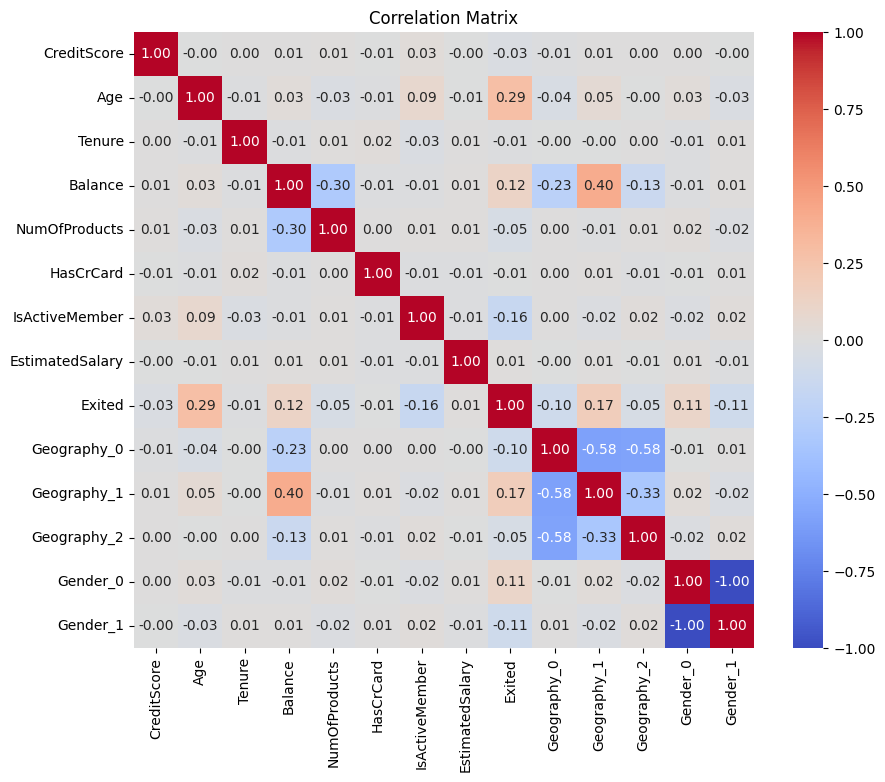

In [24]:
# Threshold parameter is used to easily identify certain features that are correlated beyond a specified threshold
def frame_correlation_matrix(df, threshold=0):
    correlation_matrix = df.corr()
    correlation_matrix[abs(correlation_matrix) < threshold] = 0
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

frame_correlation_matrix(data_frame)

## Highlight Features that are Correlated Beyond a Specified Threshold

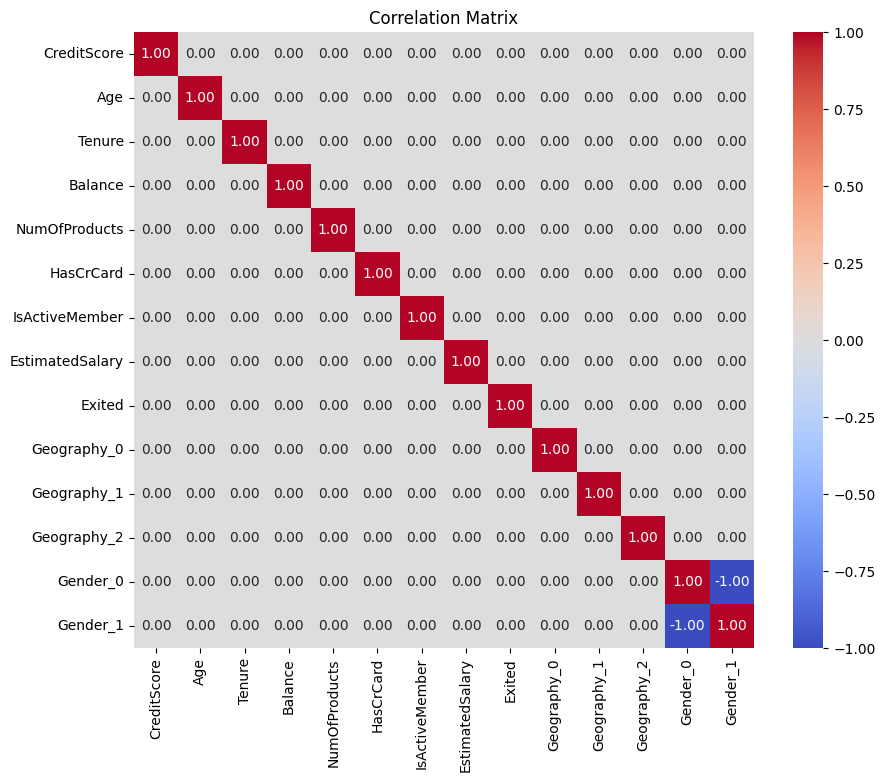

In [25]:
CORRELATION_THRESHOLD_FOR_FEATURE_REMOVAL = 0.8
frame_correlation_matrix(data_frame, CORRELATION_THRESHOLD_FOR_FEATURE_REMOVAL)

## Drop One Gender Column to Reduce Dimensionality and Information Redundancy
We do this because it is highly correlated with the other Gender column.

In [26]:
data_frame = data_frame.drop(columns=["Gender_1"])
data_frame.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_0,Geography_1,Geography_2,Gender_0
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True


## Define Unscaled Features (x) and Target (y)

In [27]:
# Define function for getting unscaled, scaled and normalized x
# This function also retrieves the unscaled Target column
def get_x_y(df, scale=False, normalize=False):
    x = df.drop(columns=[TARGET])
    if scale:
        x = get_scaled_frame(x)
    elif normalize:
        x = get_normalized_frame(x)
    y = df[TARGET]
    return x, y

x, y = get_x_y(data_frame)

x.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True


## Define Scaled Features (x_scaled)

In [36]:
x_scaled, _ = get_x_y(data_frame, scale=True)
x_scaled.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809,1.095988
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740,1.095988
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809,1.095988


## Define Normalized Features (x_normalized)

In [37]:
x_normalized, _ = get_x_y(data_frame, scale=False, normalize=True)
x_normalized.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,0.006108,0.000414,0.000020,0.000000,0.000010,0.000010,0.000010,0.999981,0.000010,0.0,0.000000,0.000010
1,0.004333,0.000292,0.000007,0.597258,0.000007,0.000000,0.000007,0.802037,0.000000,0.0,0.000007,0.000007
2,0.002559,0.000214,0.000041,0.814000,0.000015,0.000005,0.000000,0.580859,0.000005,0.0,0.000000,0.000005


## Define Helper Functions for Conveniently Testing Models

In [39]:
def call_train_test_split(x, y, train_size=0.8):
    return train_test_split(x, y, train_size=train_size, test_size=(1 - train_size), random_state=RANDOM_STATE, stratify=y)

def custom_train_test_split(x, y, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False, train_size=0.8):
    """
    Returns training and test sets for x and y respectively (x_train, x_test, y_train, y_test)
    x_train and y_train exclude any of the outliers specified in outliers_to_remove
    x_train and y_train upsample the minority class if upsample_minority == True
    x_train and y_train use a method to generate synthetic data points if add_synthetic_training_data == True
    train_size controls the size of the training data and test data respectively where test_size == 1 - train_size

    x_test and y_test are sampled in their raw form without any processing so that when we test our models, 
    it simulates how the model would actually perform in a real world scenario.
    """
    x_train, x_test, y_train, y_test = call_train_test_split(x, y, train_size)
    
    # https://stackoverflow.com/questions/74683825/how-do-i-remove-outliers-from-a-column-in-a-dataframe
    # Reconstruct data frame using x and y. Essentially, concatenate x with y to produce the original dataframe.
    # This is done because we need to keep x and y consistent with each other.
    df_train = x.copy()
    df_train[TARGET] = y
    if outliers_to_remove:
        # When we remove an outlier from x, we also need to remove the corresponding row in y.
        for outlier in outliers_to_remove:
            quartile1 = df_train[outlier].quantile(0.25)
            quartile3 = df_train[outlier].quantile(0.75)
            interquartile_range = quartile3 - quartile1

            low = quartile1 - 1.5 * interquartile_range
            high = quartile3 + 1.5 * interquartile_range

            df_train = df_train[df_train[outlier] > low]
            df_train = df_train[df_train[outlier] < high]

        x_removed_outliers, y_removed_outliers = get_x_y(df_train)
        # Update x_train and y_train to only include rows without any outliers
        x_train, _, y_train, _ = call_train_test_split(x_removed_outliers, y_removed_outliers)

    if upsample_minority:
        df_train_minority = df_train[df_train[TARGET] == 1]
        df_train_majority = df_train[df_train[TARGET] == 0]

        df_train_minority_upsample = resample(df_train_minority, replace=True, n_samples=len(df_train_majority), random_state=RANDOM_STATE)
        df_train_upsample = pd.concat([df_train_majority, df_train_minority_upsample])

        x_minority_upsample, y_minority_upsample = get_x_y(df_train_upsample)
        # Update x_train and y_train to have upsampled the minority class
        x_train, _, y_train, _ = call_train_test_split(x_minority_upsample, y_minority_upsample)

    if add_synthetic_training_data:
        # Update x_train and y_train to include synthetic data based on one of the recommended techniques below
        adasyn = ADASYN(random_state=RANDOM_STATE)
        smote = SMOTE(random_state=RANDOM_STATE)
        smote_enn = SMOTEENN(random_state=RANDOM_STATE)
        
        if add_synthetic_training_data.upper() == "ADASYN":
            x_train, y_train = adasyn.fit_resample(x_train, y_train)
            
        elif add_synthetic_training_data.upper() == "SMOTE":
            x_train, y_train = smote.fit_resample(x_train, y_train)

        # Default case applies SMOTEENN
        else:
            x_train, y_train = smote_enn.fit_resample(x_train, y_train)
    
    return x_train, x_test, y_train, y_test

def test_model(model, x, y, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False, output=True, train_size=0.8):
    """
    Returns the fitted model, training and test f1 scores respectively (model, training_f1_score, test_f1_score).
    
    Splits data into training and test sets based on the specified parameters. See the custom_train_test_split() function for more information.
    Model is then fitted on the training data.
    The model then tries to predict the training and test sets.

    If output == True, information about the model and how the Training Data was transformed is shown to the user.
    The Training and Test Classification Report is then printed. A Confusion Matrix visual is shown.
    If the model has a function called "predict_proba", it will plot a ROC Curve.
    If the model is a Decision Tree, it will show a visual of the tree model.
    """
    x_train, x_test, y_train, y_test = custom_train_test_split(x, y, outliers_to_remove, upsample_minority, add_synthetic_training_data)
    model.fit(x_train, y_train)
    y_train_predicted = model.predict(x_train)
    y_test_predicted = model.predict(x_test)

    if output:
        print(model)
        print(f"{outliers_to_remove=}, {upsample_minority=}, {add_synthetic_training_data=}")
        print("\nTraining Report:")
        print(classification_report(y_train, y_train_predicted))
        print("\nTest Report and Results:")
        print(classification_report(y_test, y_test_predicted))
    
        confusion_matrix_test = confusion_matrix(y_test, y_test_predicted)
        confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix_test, display_labels=model.classes_)
        figure, axes = plt.subplots(figsize=(2, 2))
        confusion_matrix_display.plot(ax=axes)
        plt.show()
    
        predict_proba = getattr(model, "predict_proba", None)
        if callable(predict_proba):
            y_test_predicted_class_probabilities = model.predict_proba(x_test)
            y_test_predicted_minority_probabilites = y_test_predicted_class_probabilities[:, 1]
            false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_test_predicted_minority_probabilites)
            area_under_curve = auc(false_positive_rate, true_positive_rate)
            plt.figure(figsize=(4, 2.5))
            # PLot straight dotted diagonal line from (0, 0) to (1, 1)
            plt.plot([0, 1], [0, 1], linestyle="--")
            # Plot true positive rate against false positive rate with a label for area under the ROC curve
            plt.plot(false_positive_rate, true_positive_rate, label=f"ROC curve (area = {area_under_curve:.2f})")
            plt.title(f"ROC Curve")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend()
            plt.show()
        
        if type(model) == type(DecisionTreeClassifier()):
            plot_tree(model, filled=True)

    training_f1_score = f1_score(y_train, y_train_predicted)
    test_f1_score = f1_score(y_test, y_test_predicted)
    return model, training_f1_score, test_f1_score

## Define Helper Function for Hyperparameter Tuning

In [111]:
def tune_hyperparameters(model, x, y, parameter_grid, search_strategy, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False):
    scoring = "f1"
    error_score = "raise"    
    assert search_strategy in ["random", "grid"], f"Invalid Search Strategy: {search_strategy}"

    x_train, _, y_train, _ = custom_train_test_split(x, y, outliers_to_remove, upsample_minority, add_synthetic_training_data)

    if search_strategy == "random":
        searchcv = RandomizedSearchCV(model, param_distributions=parameter_grid, random_state=RANDOM_STATE, scoring=scoring, error_score=error_score)
    else:
        searchcv = GridSearchCV(model, param_grid=parameter_grid, scoring=scoring, error_score=error_score)
    searchcv.fit(x_train, y_train)

    tuned_model = searchcv.best_estimator_
    print(f"{tuned_model=}")
    return tuned_model

## Define Helper Function To Generate "class_weight" Parameters for Various Models

In [112]:
def generate_binary_class_weights(rate_of_change=0.05, majority_class=0, minority_class=1):
    class_weights = []
    assert rate_of_change > 0
    majority_value = 1 - rate_of_change
    minority_value = 1 - majority_value
    while majority_value > 0 and minority_value < 1:
        class_weight = {}
        class_weight[majority_class] = round(majority_value, 2)
        class_weight[minority_class] = round(1 - majority_value, 2)

        majority_value -= rate_of_change

        class_weights.append(class_weight)

    return class_weights

CLASS_WEIGHTS = generate_binary_class_weights()

# Testing Untuned Models Trained on Samples of Uncleaned Data (x_train_uncleaned)

In [68]:
x_train_uncleaned, _, _, _ = custom_train_test_split(x, y, outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_uncleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
9385,687,44,8,95368.14,2,1,1,1787.85,False,True,False,False
2155,660,35,6,100768.77,1,1,0,19199.61,True,False,False,True
768,684,41,2,119782.72,2,0,0,120284.67,False,False,True,False


## Decision Tree

DecisionTreeClassifier(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1630

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1593
           1       0.49      0.50      0.50       407

    accuracy                           0.79      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000



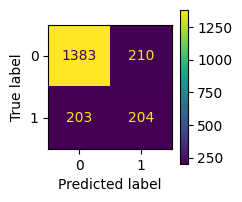

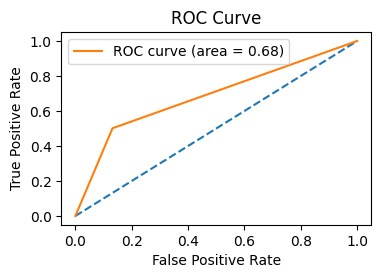

(DecisionTreeClassifier(random_state=123), 1.0, 0.49695493300852617)

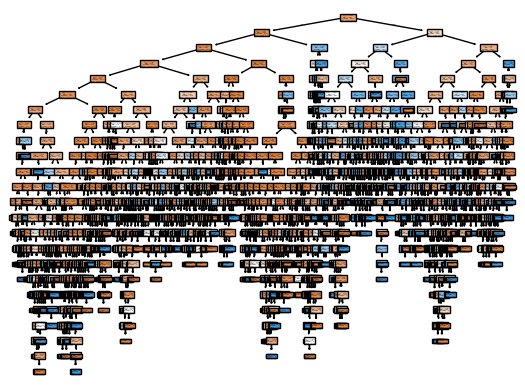

In [87]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
test_model(tree, x_scaled, y)

## Support Vector Machine

SVC(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6370
           1       0.00      0.00      0.00      1630

    accuracy                           0.80      8000
   macro avg       0.40      0.50      0.44      8000
weighted avg       0.63      0.80      0.71      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

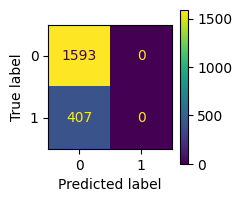

(SVC(random_state=123), 0.0, 0.0)

In [60]:
svm = SVC(random_state=RANDOM_STATE)
test_model(svm, x, y)

## Multilayer Perceptron

MLPClassifier(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      6370
           1       0.25      0.31      0.27      1630

    accuracy                           0.67      8000
   macro avg       0.53      0.53      0.53      8000
weighted avg       0.70      0.67      0.68      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      1593
           1       0.24      0.31      0.27       407

    accuracy                           0.66      2000
   macro avg       0.53      0.53      0.53      2000
weighted avg       0.69      0.66      0.68      2000



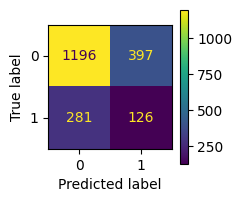

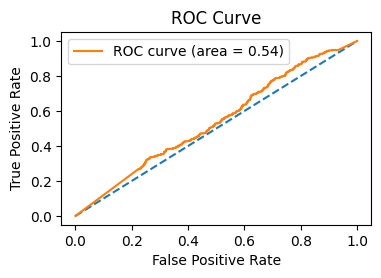

(MLPClassifier(random_state=123), 0.2739427012278308, 0.2709677419354839)

In [61]:
mlp = MLPClassifier(random_state=RANDOM_STATE)
test_model(mlp, x, y)

## Logistic Regression

LogisticRegression(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      6370
           1       0.43      0.07      0.12      1630

    accuracy                           0.79      8000
   macro avg       0.62      0.52      0.50      8000
weighted avg       0.73      0.79      0.73      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1593
           1       0.42      0.07      0.13       407

    accuracy                           0.79      2000
   macro avg       0.61      0.52      0.50      2000
weighted avg       0.73      0.79      0.73      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


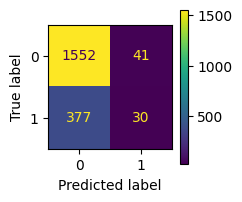

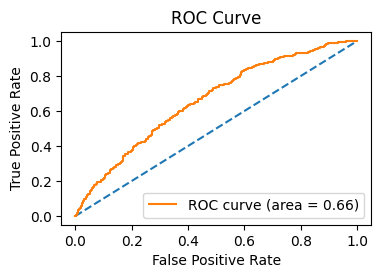

(LogisticRegression(random_state=123),
 0.12480335605663345,
 0.12552301255230125)

In [62]:
lr = LogisticRegression(random_state=RANDOM_STATE)
test_model(lr, x, y)

## Naive Bayes

GaussianNB()
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.88      6370
           1       0.38      0.08      0.14      1630

    accuracy                           0.79      8000
   macro avg       0.59      0.52      0.51      8000
weighted avg       0.72      0.79      0.73      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1593
           1       0.33      0.09      0.14       407

    accuracy                           0.78      2000
   macro avg       0.57      0.52      0.50      2000
weighted avg       0.71      0.78      0.72      2000



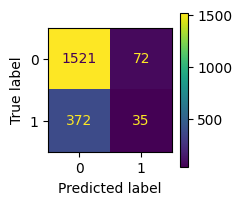

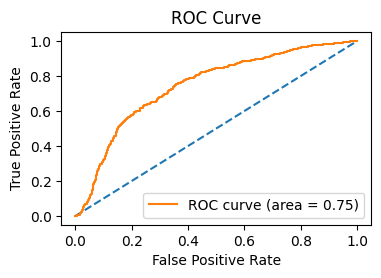

(GaussianNB(), 0.13855421686746988, 0.13618677042801555)

In [63]:
nb = GaussianNB()
test_model(nb, x, y)

## Random Forest

RandomForestClassifier(random_state=123)
outliers_to_remove=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1630

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.51      0.62       407

    accuracy                           0.87      2000
   macro avg       0.84      0.74      0.77      2000
weighted avg       0.87      0.87      0.86      2000



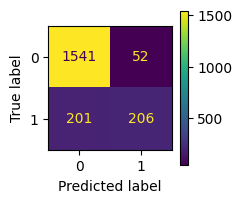

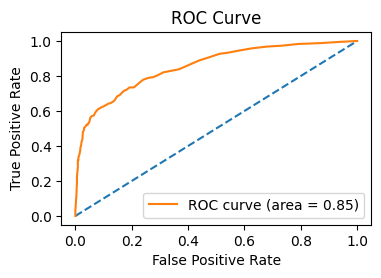

(RandomForestClassifier(random_state=123), 1.0, 0.6195488721804512)

In [64]:
forest = RandomForestClassifier(random_state=RANDOM_STATE)
test_model(forest, x, y)

# Testing Untuned Models Trained on Samples of Cleaned Data (x_train_cleaned)
Cleaning the data here involved dropping the outliers we selected earlier (i.e. the outliers in the NumOfProducts column).

In [88]:
x_train_cleaned, _, _, _ = custom_train_test_split(x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_cleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
3549,675,61,5,62055.17,3,1,0,166305.16,True,False,False,True
5961,796,32,5,102773.15,2,0,1,117832.88,False,False,True,False
7938,805,39,2,0.00,1,0,0,166650.32,True,False,False,False


## Decision Tree

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1582

    accuracy                           1.00      7952
   macro avg       1.00      1.00      1.00      7952
weighted avg       1.00      1.00      1.00      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      1593
           1       0.64      0.89      0.74       407

    accuracy                           0.87      2000
   macro avg       0.80      0.88      0.83      2000
weighted avg       0.90      0.87      0.88      2000



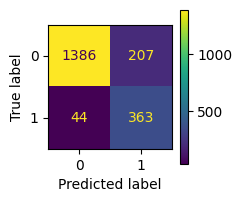

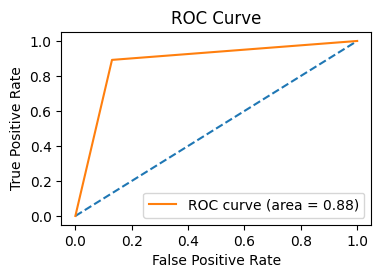

(DecisionTreeClassifier(random_state=123), 1.0, 0.7430910951893551)

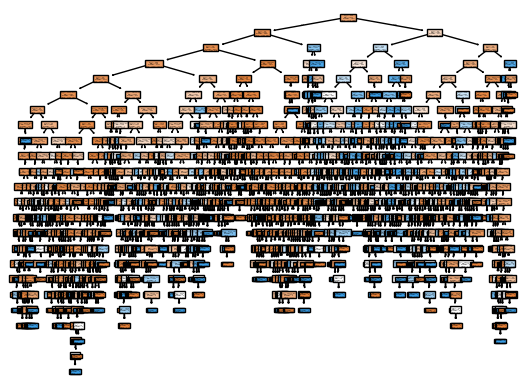

In [89]:
test_model(tree, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Support Vector Machine

SVC(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6370
           1       0.00      0.00      0.00      1582

    accuracy                           0.80      7952
   macro avg       0.40      0.50      0.44      7952
weighted avg       0.64      0.80      0.71      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

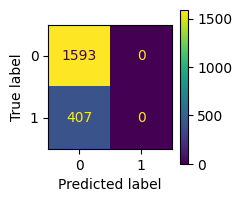

(SVC(random_state=123), 0.0, 0.0)

In [90]:
test_model(svm, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Multilayer Perceptron (MLP)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6370
           1       0.17      0.00      0.00      1582

    accuracy                           0.80      7952
   macro avg       0.48      0.50      0.45      7952
weighted avg       0.67      0.80      0.71      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



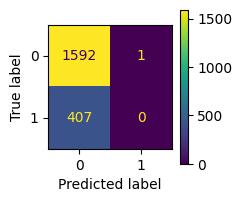

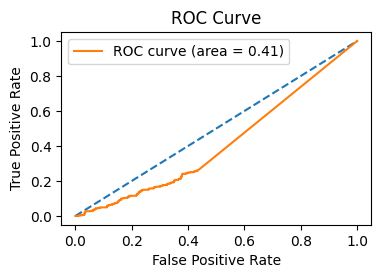

(MLPClassifier(random_state=123), 0.0012594458438287153, 0.0)

In [91]:
test_model(mlp, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Logistic Regression

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      6370
           1       0.43      0.09      0.15      1582

    accuracy                           0.80      7952
   macro avg       0.62      0.53      0.52      7952
weighted avg       0.74      0.80      0.74      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1593
           1       0.45      0.10      0.16       407

    accuracy                           0.79      2000
   macro avg       0.63      0.53      0.52      2000
weighted avg       0.74      0.79      0.74      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


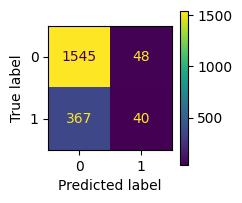

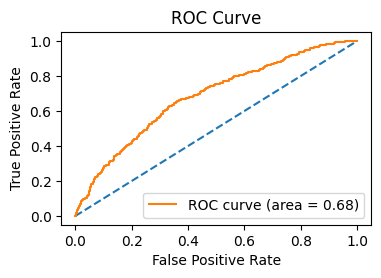

(LogisticRegression(random_state=123),
 0.14682747771368643,
 0.16161616161616163)

In [92]:
test_model(lr, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Naive Bayes

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      6370
           1       0.39      0.09      0.14      1582

    accuracy                           0.79      7952
   macro avg       0.60      0.53      0.51      7952
weighted avg       0.73      0.79      0.73      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1593
           1       0.34      0.09      0.14       407

    accuracy                           0.78      2000
   macro avg       0.57      0.52      0.51      2000
weighted avg       0.71      0.78      0.72      2000



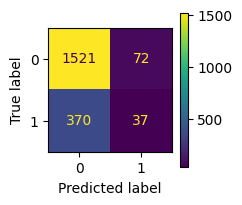

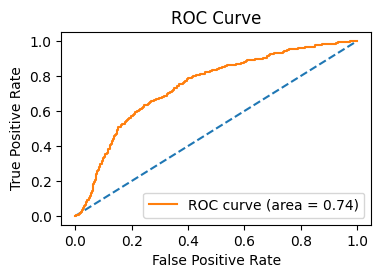

(GaussianNB(), 0.144912641315519, 0.1434108527131783)

In [93]:
test_model(nb, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Random Forest

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1582

    accuracy                           1.00      7952
   macro avg       1.00      1.00      1.00      7952
weighted avg       1.00      1.00      1.00      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1593
           1       0.85      0.89      0.87       407

    accuracy                           0.95      2000
   macro avg       0.91      0.92      0.92      2000
weighted avg       0.95      0.95      0.95      2000



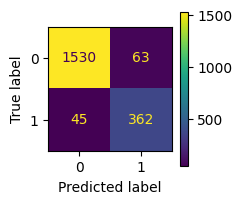

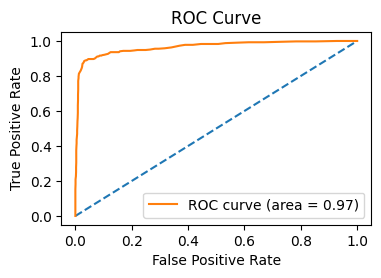

(RandomForestClassifier(random_state=123), 1.0, 0.8701923076923077)

In [94]:
test_model(forest, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

# Testing Untuned Models Trained on Samples of Scaled & Cleaned Data

## Standardized & Cleaned Data (x_train_scaled_cleaned)

In [103]:
x_train_scaled_cleaned, _, _, _ = custom_train_test_split(x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_scaled_cleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
3549,0.253198,2.105236,-0.004426,-0.231283,2.527057,0.646092,-1.030670,1.151411,0.997204,-0.578736,-0.573809,1.095988
5961,1.505158,-0.660018,-0.004426,0.421309,0.807737,-1.547768,0.970243,0.308527,-1.002804,-0.578736,1.742740,-0.912419
7938,1.598279,0.007457,-1.041760,-1.225848,-0.911583,-1.547768,-1.030670,1.157413,0.997204,-0.578736,-0.573809,-0.912419


## Normalized & Cleaned Data (x_train_normalized_cleaned)

In [104]:
x_train_normalized_cleaned, _, _, _ = custom_train_test_split(x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data=False, train_size=0.8)
x_train_normalized_cleaned.head(NUM_ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
8636,0.005724,0.000438,0.000019,0.950306,0.000010,0.000010,0.000010,0.311263,0.000010,0.0,0.000000,0.000000
3789,0.002790,0.000206,0.000018,0.408292,0.000005,0.000005,0.000005,0.912847,0.000000,0.0,0.000005,0.000005
1973,0.004431,0.000262,0.000026,0.000000,0.000013,0.000000,0.000000,0.999990,0.000006,0.0,0.000000,0.000000


## Decision Tree

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1582

    accuracy                           1.00      7952
   macro avg       1.00      1.00      1.00      7952
weighted avg       1.00      1.00      1.00      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      1593
           1       0.64      0.89      0.74       407

    accuracy                           0.87      2000
   macro avg       0.80      0.88      0.83      2000
weighted avg       0.90      0.87      0.88      2000



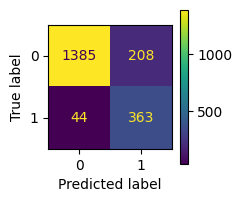

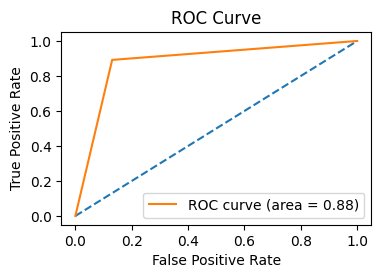

(DecisionTreeClassifier(random_state=123), 1.0, 0.7423312883435583)

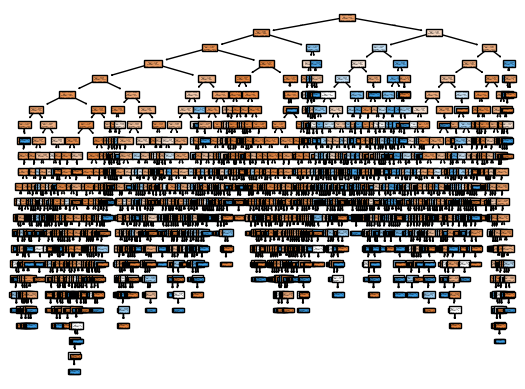

In [107]:
test_model(tree, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      1513

    accuracy                           1.00      7120
   macro avg       1.00      1.00      1.00      7120
weighted avg       1.00      1.00      1.00      7120


Test Report and Results:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1593
           1       0.75      0.86      0.81       407

    accuracy                           0.92      2000
   macro avg       0.86      0.90      0.88      2000
weighted avg       0.92      0.92      0.92      2000



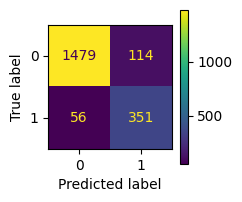

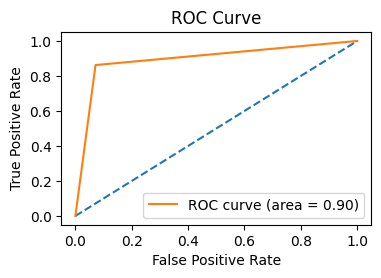

(DecisionTreeClassifier(random_state=123), 1.0, 0.805045871559633)

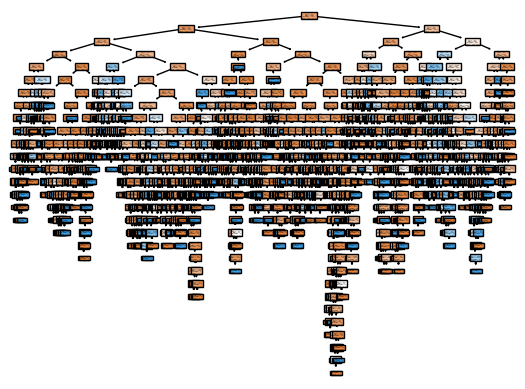

In [108]:
test_model(tree, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Support Vector Machine

SVC(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      6370
           1       0.83      0.41      0.55      1582

    accuracy                           0.87      7952
   macro avg       0.85      0.70      0.74      7952
weighted avg       0.86      0.87      0.85      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



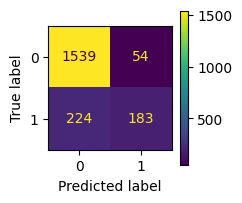

(SVC(random_state=123), 0.550761421319797, 0.5683229813664596)

In [127]:
test_model(svm, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

SVC(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5607
           1       0.00      0.00      0.00      1513

    accuracy                           0.79      7120
   macro avg       0.39      0.50      0.44      7120
weighted avg       0.62      0.79      0.69      7120


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

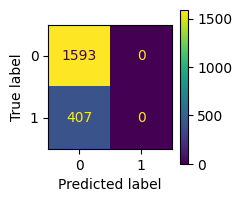

(SVC(random_state=123), 0.0, 0.0)

In [128]:
test_model(svm, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Multilayer Perceptron (MLP)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      6370
           1       0.80      0.55      0.65      1582

    accuracy                           0.88      7952
   macro avg       0.85      0.76      0.79      7952
weighted avg       0.88      0.88      0.87      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1593
           1       0.73      0.57      0.64       407

    accuracy                           0.87      2000
   macro avg       0.81      0.76      0.78      2000
weighted avg       0.86      0.87      0.86      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


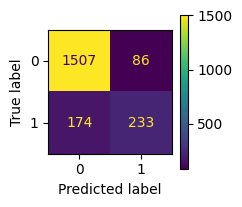

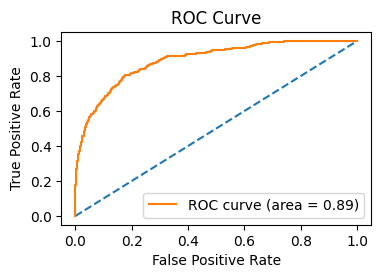

(MLPClassifier(random_state=123), 0.6478978978978979, 0.6418732782369146)

In [129]:
test_model(mlp, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5607
           1       0.00      0.00      0.00      1513

    accuracy                           0.79      7120
   macro avg       0.39      0.50      0.44      7120
weighted avg       0.62      0.79      0.69      7120


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

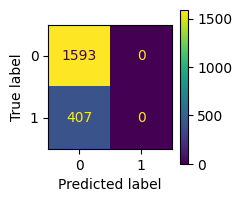

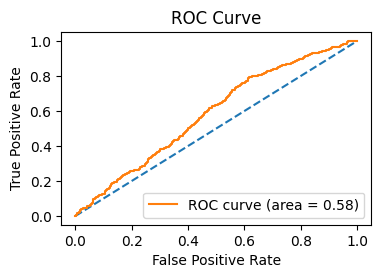

(MLPClassifier(random_state=123), 0.0, 0.0)

In [130]:
test_model(mlp, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Logistic Regression

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      6370
           1       0.61      0.22      0.33      1582

    accuracy                           0.82      7952
   macro avg       0.72      0.59      0.61      7952
weighted avg       0.79      0.82      0.78      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1593
           1       0.58      0.24      0.34       407

    accuracy                           0.81      2000
   macro avg       0.71      0.60      0.62      2000
weighted avg       0.78      0.81      0.78      2000



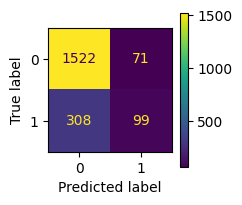

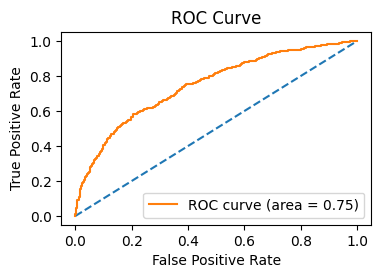

(LogisticRegression(random_state=123), 0.32668213457076567, 0.3431542461005199)

In [131]:
test_model(lr, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5607
           1       0.00      0.00      0.00      1513

    accuracy                           0.79      7120
   macro avg       0.39      0.50      0.44      7120
weighted avg       0.62      0.79      0.69      7120


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

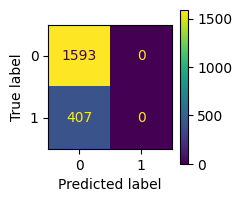

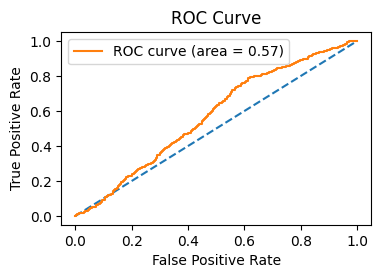

(LogisticRegression(random_state=123), 0.0, 0.0)

In [132]:
test_model(lr, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Naive Bayes

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      6370
           1       0.55      0.35      0.43      1582

    accuracy                           0.81      7952
   macro avg       0.70      0.64      0.66      7952
weighted avg       0.79      0.81      0.80      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.86      0.92      0.88      1593
           1       0.55      0.40      0.46       407

    accuracy                           0.81      2000
   macro avg       0.70      0.66      0.67      2000
weighted avg       0.79      0.81      0.80      2000



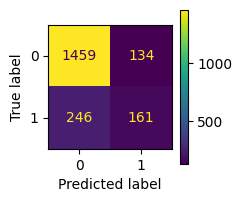

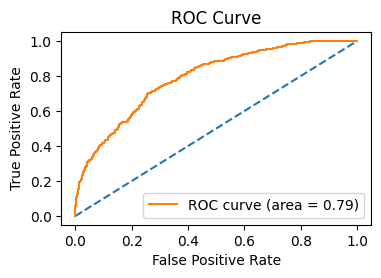

(GaussianNB(), 0.42520293776575185, 0.4586894586894587)

In [133]:
test_model(nb, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.79      0.98      0.88      5607
           1       0.36      0.04      0.08      1513

    accuracy                           0.78      7120
   macro avg       0.58      0.51      0.48      7120
weighted avg       0.70      0.78      0.71      7120


Test Report and Results:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1593
           1       0.14      0.08      0.10       407

    accuracy                           0.71      2000
   macro avg       0.46      0.48      0.47      2000
weighted avg       0.66      0.71      0.68      2000



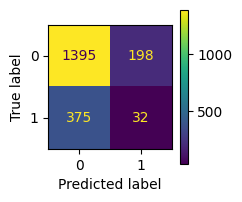

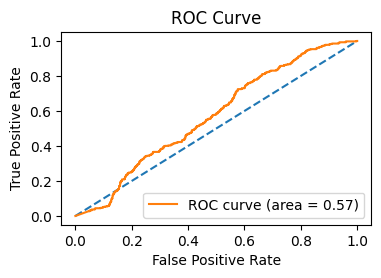

(GaussianNB(), 0.07569485511531639, 0.10047095761381476)

In [134]:
test_model(nb, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

## Random Forest

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1582

    accuracy                           1.00      7952
   macro avg       1.00      1.00      1.00      7952
weighted avg       1.00      1.00      1.00      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1593
           1       0.85      0.89      0.87       407

    accuracy                           0.95      2000
   macro avg       0.91      0.92      0.92      2000
weighted avg       0.95      0.95      0.95      2000



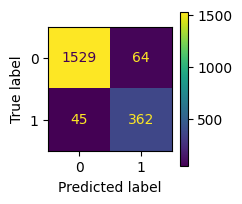

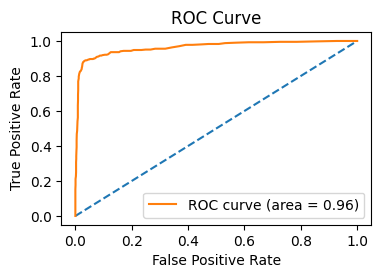

(RandomForestClassifier(random_state=123), 1.0, 0.8691476590636255)

In [135]:
test_model(forest, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      1513

    accuracy                           1.00      7120
   macro avg       1.00      1.00      1.00      7120
weighted avg       1.00      1.00      1.00      7120


Test Report and Results:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1593
           1       0.86      0.84      0.85       407

    accuracy                           0.94      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.94      0.94      0.94      2000



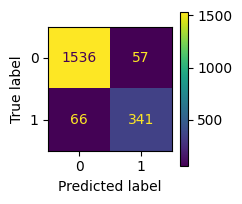

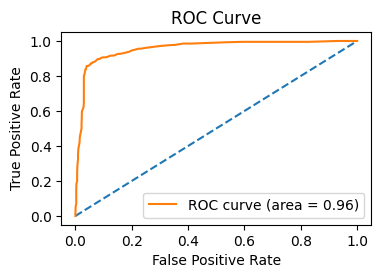

(RandomForestClassifier(random_state=123), 1.0, 0.8472049689440994)

In [136]:
test_model(forest, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING)

# Addressing Class Imbalance using the Most Favorable Preprocessing Techniques specific to each Model from the Previous Step

## Decision Tree

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      5607

    accuracy                           1.00     11214
   macro avg       1.00      1.00      1.00     11214
weighted avg       1.00      1.00      1.00     11214


Test Report and Results:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1593
           1       0.82      0.91      0.86       407

    accuracy                           0.94      2000
   macro avg       0.90      0.93      0.91      2000
weighted avg       0.94      0.94      0.94      2000



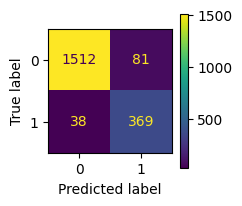

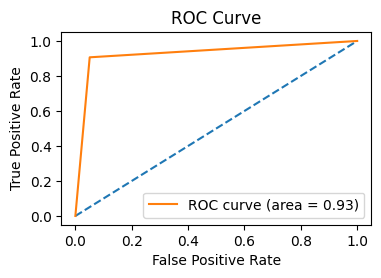

(DecisionTreeClassifier(random_state=123), 1.0, 0.8611435239206534)

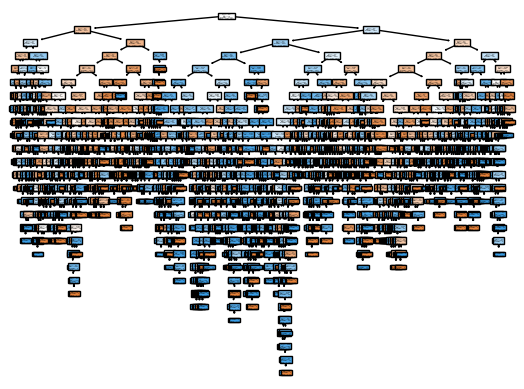

In [109]:
test_model(tree, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

DecisionTreeClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      5814

    accuracy                           1.00     11421
   macro avg       1.00      1.00      1.00     11421
weighted avg       1.00      1.00      1.00     11421


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1593
           1       0.75      0.87      0.81       407

    accuracy                           0.92      2000
   macro avg       0.86      0.90      0.88      2000
weighted avg       0.92      0.92      0.92      2000



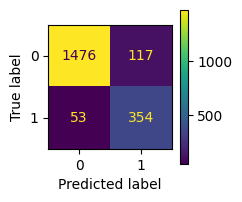

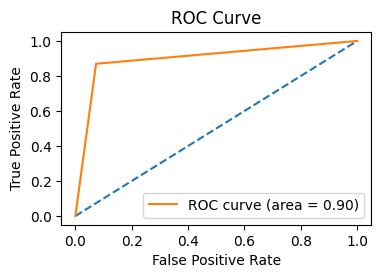

(DecisionTreeClassifier(random_state=123), 1.0, 0.806378132118451)

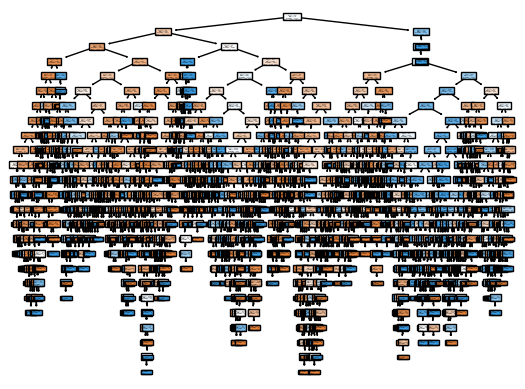

In [110]:
test_model(tree, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Support Vector Machine

SVC(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      6370
           1       0.82      0.80      0.81      6370

    accuracy                           0.81     12740
   macro avg       0.81      0.81      0.81     12740
weighted avg       0.81      0.81      0.81     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      1593
           1       0.52      0.80      0.63       407

    accuracy                           0.81      2000
   macro avg       0.73      0.80      0.75      2000
weighted avg       0.85      0.81      0.82      2000



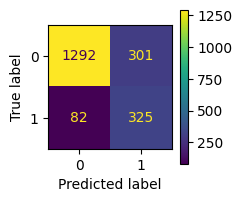

(SVC(random_state=123), 0.8099952099632763, 0.6292352371732817)

In [142]:
test_model(svm, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

SVC(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      6370
           1       0.79      0.85      0.82      6411

    accuracy                           0.81     12781
   macro avg       0.81      0.81      0.81     12781
weighted avg       0.81      0.81      0.81     12781


Test Report and Results:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1593
           1       0.46      0.86      0.60       407

    accuracy                           0.77      2000
   macro avg       0.71      0.80      0.72      2000
weighted avg       0.85      0.77      0.79      2000



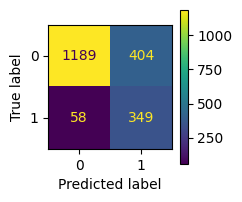

(SVC(random_state=123), 0.8160048044441108, 0.6017241379310345)

In [143]:
test_model(svm, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Multilayer Perceptron (MLP)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      6370
           1       0.84      0.84      0.84      6370

    accuracy                           0.84     12740
   macro avg       0.84      0.84      0.84     12740
weighted avg       0.84      0.84      0.84     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1593
           1       0.52      0.82      0.63       407

    accuracy                           0.81      2000
   macro avg       0.73      0.81      0.75      2000
weighted avg       0.86      0.81      0.82      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


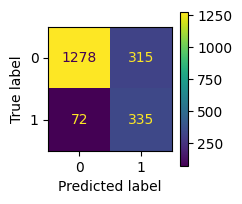

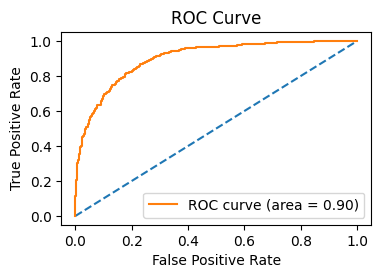

(MLPClassifier(random_state=123), 0.8415008259262172, 0.6338694418164617)

In [150]:
test_model(mlp, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

MLPClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      6370
           1       0.84      0.87      0.86      6411

    accuracy                           0.85     12781
   macro avg       0.85      0.85      0.85     12781
weighted avg       0.85      0.85      0.85     12781


Test Report and Results:
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      1593
           1       0.53      0.84      0.65       407

    accuracy                           0.82      2000
   macro avg       0.74      0.82      0.76      2000
weighted avg       0.87      0.82      0.83      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


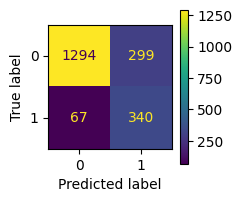

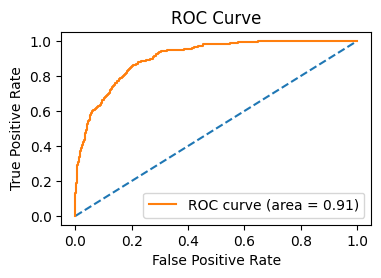

(MLPClassifier(random_state=123), 0.8565953859124703, 0.6500956022944551)

In [151]:
test_model(mlp, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Logistic Regression

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6370
           1       0.71      0.69      0.70      6370

    accuracy                           0.71     12740
   macro avg       0.71      0.71      0.71     12740
weighted avg       0.71      0.71      0.71     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1593
           1       0.37      0.65      0.47       407

    accuracy                           0.70      2000
   macro avg       0.63      0.68      0.63      2000
weighted avg       0.78      0.70      0.72      2000



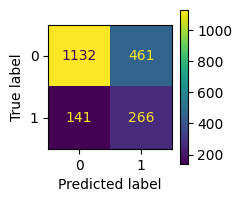

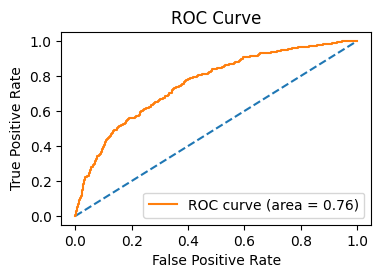

(LogisticRegression(random_state=123), 0.7014127224838375, 0.4691358024691358)

In [159]:
test_model(lr, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

LogisticRegression(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      6370
           1       0.69      0.68      0.69      6411

    accuracy                           0.69     12781
   macro avg       0.69      0.69      0.69     12781
weighted avg       0.69      0.69      0.69     12781


Test Report and Results:
              precision    recall  f1-score   support

           0       0.90      0.68      0.77      1593
           1       0.36      0.69      0.47       407

    accuracy                           0.68      2000
   macro avg       0.63      0.69      0.62      2000
weighted avg       0.79      0.68      0.71      2000



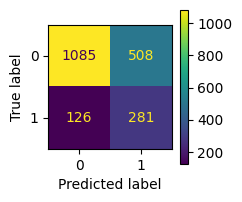

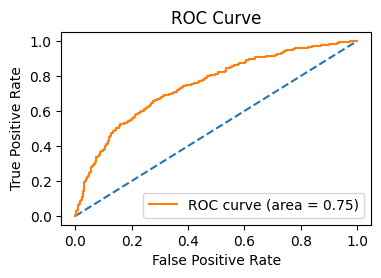

(LogisticRegression(random_state=123), 0.6877253488007524, 0.4698996655518395)

In [160]:
test_model(lr, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Naive Bayes

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.71      6370
           1       0.72      0.68      0.70      6370

    accuracy                           0.71     12740
   macro avg       0.71      0.71      0.71     12740
weighted avg       0.71      0.71      0.71     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1593
           1       0.40      0.72      0.51       407

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.66      2000
weighted avg       0.81      0.72      0.75      2000



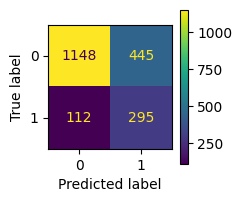

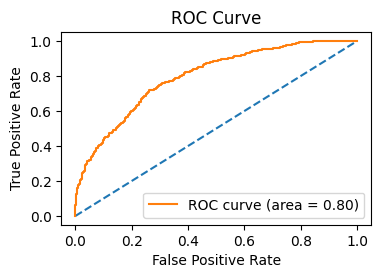

(GaussianNB(), 0.698637865720964, 0.5143853530950305)

In [164]:
test_model(nb, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      6370
           1       0.69      0.68      0.69      6411

    accuracy                           0.69     12781
   macro avg       0.69      0.69      0.69     12781
weighted avg       0.69      0.69      0.69     12781


Test Report and Results:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1593
           1       0.39      0.77      0.52       407

    accuracy                           0.71      2000
   macro avg       0.66      0.73      0.66      2000
weighted avg       0.81      0.71      0.74      2000



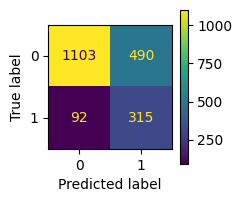

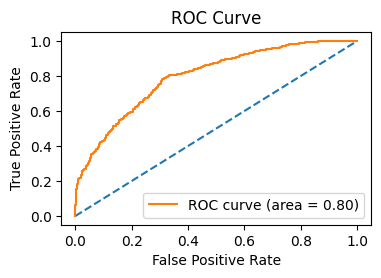

(GaussianNB(), 0.6857684110821691, 0.5198019801980198)

In [165]:
test_model(nb, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Random Forest

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      6370

    accuracy                           1.00     12740
   macro avg       1.00      1.00      1.00     12740
weighted avg       1.00      1.00      1.00     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1593
           1       0.75      0.99      0.85       407

    accuracy                           0.93      2000
   macro avg       0.87      0.95      0.90      2000
weighted avg       0.95      0.93      0.93      2000



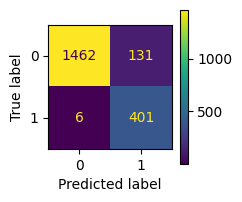

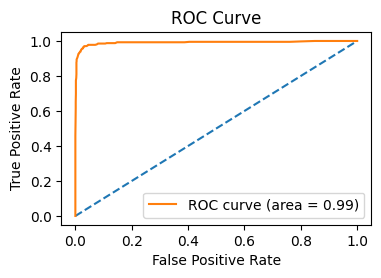

(RandomForestClassifier(random_state=123), 1.0, 0.8541001064962727)

In [174]:
test_model(forest, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      6295

    accuracy                           1.00     12665
   macro avg       1.00      1.00      1.00     12665
weighted avg       1.00      1.00      1.00     12665


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      1593
           1       0.69      0.90      0.78       407

    accuracy                           0.90      2000
   macro avg       0.83      0.90      0.86      2000
weighted avg       0.91      0.90      0.90      2000



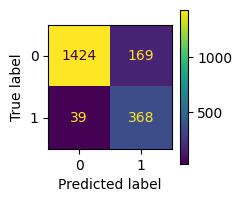

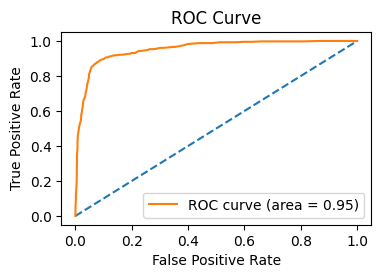

(RandomForestClassifier(random_state=123), 1.0, 0.7796610169491526)

In [172]:
test_model(forest, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

# Tune Hyperparameters

## Decision Tree

tuned_model=DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, random_state=123)
DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      5607

    accuracy                           1.00     11214
   macro avg       1.00      1.00      1.00     11214
weighted avg       1.00      1.00      1.00     11214


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1593
           1       0.89      0.89      0.89       407

    accuracy                           0.95      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.95      0.95      0.95      2000



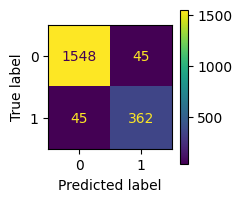

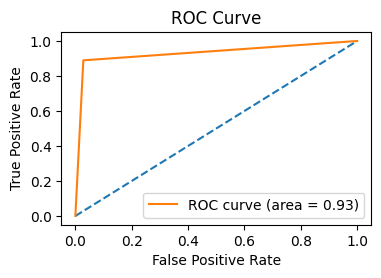

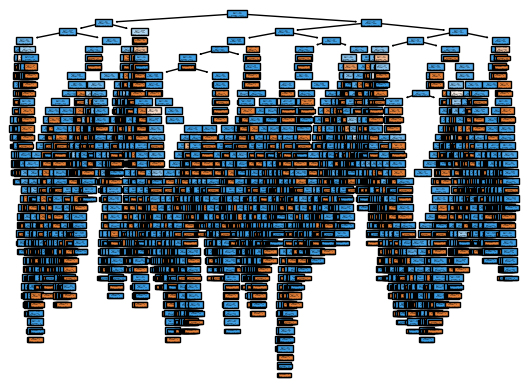

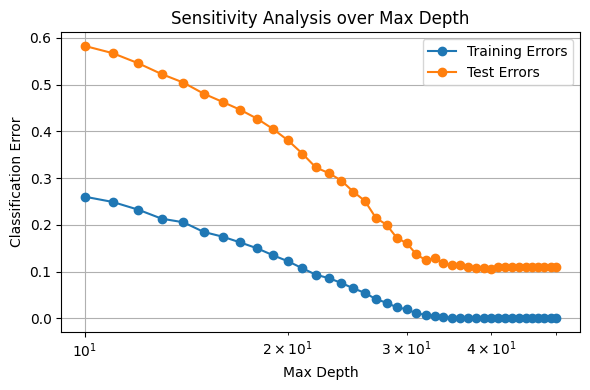

In [123]:
weighted_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_parameter_grid = {"class_weight": CLASS_WEIGHTS}
weighted_tree = tune_hyperparameters(weighted_tree, x_normalized, y, tree_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, add_synthetic_training_data=False, search_strategy="grid")
test_model(weighted_tree, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

training_errors = []
test_errors = []
max_depth_values = range(10, 51)
for max_depth in max_depth_values:
    weighted_tree.max_depth = max_depth
    _, training_score, test_score = test_model(weighted_tree, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, output=False)
    training_errors.append(1 - training_score)
    test_errors.append(1 - test_score)

plt.figure(figsize=(6, 4))
plt.plot(max_depth_values, training_errors, marker="o", label="Training Errors")
plt.plot(max_depth_values, test_errors, marker="o", label="Test Errors")
plt.title("Sensitivity Analysis over Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Classification Error")
plt.xticks(max_depth_values)
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.show()

In [124]:
tree_parameter_grid = {"max_depth": range(10,51)}
tuned_tree = tune_hyperparameters(weighted_tree, x_normalized, y, tree_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, search_strategy="grid")

tuned_model=DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, max_depth=45,
                       random_state=123)


## Decision Tree Cost Complexity Pruning

In [125]:
x_train, _, y_train, _ = custom_train_test_split(x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)
cost_complexity_pruning_path = tuned_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = cost_complexity_pruning_path.ccp_alphas

test_scores = []
best_f1_pruned = 0
best_ccp_alpha = 0


for ccp_alpha in ccp_alphas:
    tuned_tree.ccp_alpha = ccp_alpha
    _, _, test_f1_pruned = test_model(tuned_tree, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, output=False)
    test_scores.append(test_f1_pruned)

    print(f"F1-score for {ccp_alpha=}: {test_f1_pruned:.2f}")
    
    if test_f1_pruned > best_f1_pruned:
        best_f1_pruned = test_f1_pruned
        best_ccp_alpha = ccp_alpha

print(f"F1 for {best_ccp_alpha=}: {best_f1_pruned}")

tuned_tree.ccp_alpha = best_ccp_alpha

F1-score for ccp_alpha=np.float64(0.0): 0.89
F1-score for ccp_alpha=np.float64(1.7820594295748886e-20): 0.89
F1-score for ccp_alpha=np.float64(1.7820594295748886e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(2.772092446005383e-20): 0.89
F1-score for ccp_alpha=np.float64(3.267108954220629e-20): 0.89
F1-score for ccp_alpha=np.float64(3.564118859149777e-20): 0.89
F1-score for ccp_alpha=np.float64(3.564118859149777e-20): 0.89
F1-score for ccp_alpha=np.float64(4.1581386690080747e-20): 0.89
F1-score for ccp_alpha=np.float64(4.1581386690080747e-20): 0.89
F1-sco

## Tuned Decision Tree

DecisionTreeClassifier(ccp_alpha=np.float64(0.0),
                       class_weight={0: 0.05, 1: 0.95}, max_depth=45,
                       random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      5607

    accuracy                           1.00     11214
   macro avg       1.00      1.00      1.00     11214
weighted avg       1.00      1.00      1.00     11214


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1593
           1       0.89      0.89      0.89       407

    accuracy                           0.95      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.95      0.95      0.95      2000



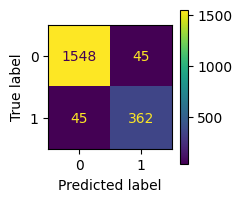

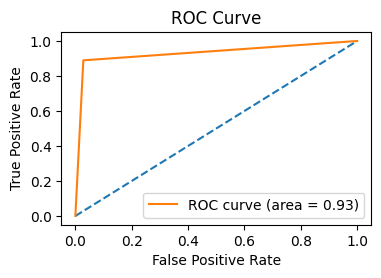

(DecisionTreeClassifier(ccp_alpha=np.float64(0.0),
                        class_weight={0: 0.05, 1: 0.95}, max_depth=45,
                        random_state=123),
 1.0,
 0.8894348894348895)

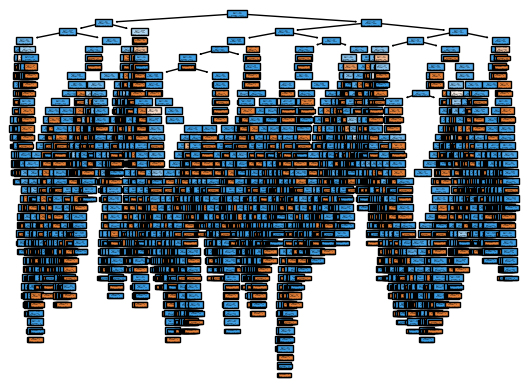

In [126]:
test_model(tuned_tree, x_normalized, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

## Support Vector Machine

In [175]:
tuned_svm = SVC(random_state=RANDOM_STATE)

svm_parameter_grid = {"kernel": ["poly", "rbf", "sigmoid"]}
tuned_svm = tune_hyperparameters(tuned_svm, x_scaled, y, svm_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, search_strategy="grid")

svm_parameter_grid = {"C": [0.1, 1, 10, 100], "gamma": [1, 0.1, 0.01, 0.001]}
tuned_svm = tune_hyperparameters(tuned_svm, x_scaled, y, svm_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, search_strategy="random")

svm_parameter_grid = {"class_weight": CLASS_WEIGHTS}
tuned_svm = tune_hyperparameters(tuned_svm, x_scaled, y, svm_parameter_grid, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True, search_strategy="random")

tuned_model=SVC(random_state=123)
tuned_model=SVC(C=10, gamma=1, random_state=123)
tuned_model=SVC(C=10, class_weight={0: 0.35, 1: 0.65}, gamma=1, random_state=123)


## Tuned Support Vector Machine

SVC(C=10, class_weight={0: 0.35, 1: 0.65}, gamma=0.1, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82      6370
           1       0.78      0.94      0.86      6370

    accuracy                           0.84     12740
   macro avg       0.86      0.84      0.84     12740
weighted avg       0.86      0.84      0.84     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       0.98      0.70      0.82      1593
           1       0.44      0.93      0.60       407

    accuracy                           0.75      2000
   macro avg       0.71      0.82      0.71      2000
weighted avg       0.87      0.75      0.77      2000



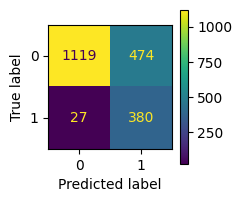

(SVC(C=10, class_weight={0: 0.35, 1: 0.65}, gamma=0.1, random_state=123),
 0.8554122425710825,
 0.6026962727993656)

In [177]:
test_model(tuned_svm, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)

## Multilayer Perceptron (MLP)

In [183]:
tuned_mlp = MLPClassifier(random_state=RANDOM_STATE, max_iter=200*3)
raise NotImplementedError

NotImplementedError: 

## Tuned Multilayer Perceptron (MLP)

MLPClassifier(max_iter=600, random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      6370
           1       0.85      0.93      0.89      6411

    accuracy                           0.88     12781
   macro avg       0.89      0.88      0.88     12781
weighted avg       0.89      0.88      0.88     12781


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88      1593
           1       0.53      0.89      0.67       407

    accuracy                           0.82      2000
   macro avg       0.75      0.84      0.77      2000
weighted avg       0.88      0.82      0.83      2000



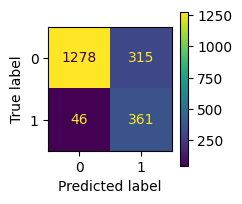

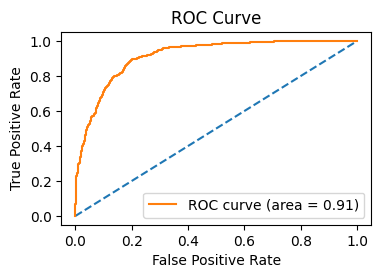

(MLPClassifier(max_iter=600, random_state=123),
 0.8894359892569382,
 0.6666666666666666)

In [185]:
test_model(tuned_mlp, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Logistic Regression
Apply Regularization

In [195]:
tuned_lr = LogisticRegression(penalty="l2", solver="liblinear", C=0.1, class_weight="balanced", max_iter=1000)
raise NotImplementedError

NotImplementedError: 

## Tuned Logistic Regression

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   solver='liblinear')
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.69      6370
           1       0.69      0.68      0.69      6411

    accuracy                           0.69     12781
   macro avg       0.69      0.69      0.69     12781
weighted avg       0.69      0.69      0.69     12781


Test Report and Results:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78      1593
           1       0.36      0.69      0.47       407

    accuracy                           0.69      2000
   macro avg       0.63      0.69      0.62      2000
weighted avg       0.79      0.69      0.71      2000



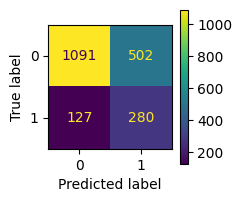

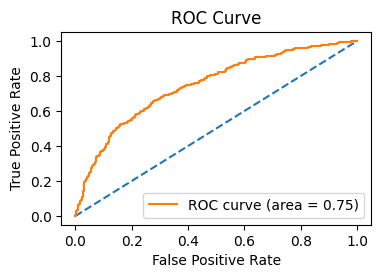

(LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                    solver='liblinear'),
 0.6866163996229971,
 0.47098402018502944)

In [196]:
test_model(tuned_lr, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Naive Bayes

In [201]:
tuned_nb = GaussianNB()
raise NotImplementedError

NotImplementedError: 

## Tuned Naive Bayes

GaussianNB()
outliers_to_remove=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data='SMOTEENN'

Training Report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      6370
           1       0.69      0.68      0.69      6411

    accuracy                           0.69     12781
   macro avg       0.69      0.69      0.69     12781
weighted avg       0.69      0.69      0.69     12781


Test Report and Results:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1593
           1       0.39      0.77      0.52       407

    accuracy                           0.71      2000
   macro avg       0.66      0.73      0.66      2000
weighted avg       0.81      0.71      0.74      2000



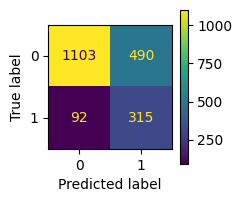

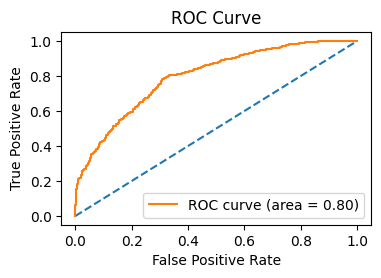

(GaussianNB(), 0.6857684110821691, 0.5198019801980198)

In [202]:
test_model(tuned_nb, x_scaled, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=False, add_synthetic_training_data="SMOTEENN")

## Random Forest

In [206]:
tuned_forest = RandomForestClassifier(random_state=RANDOM_STATE)
raise NotImplementedError

NotImplementedError: 

## Tuned Random Forest

RandomForestClassifier(random_state=123)
outliers_to_remove=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      6370

    accuracy                           1.00     12740
   macro avg       1.00      1.00      1.00     12740
weighted avg       1.00      1.00      1.00     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1593
           1       0.75      0.99      0.85       407

    accuracy                           0.93      2000
   macro avg       0.87      0.95      0.90      2000
weighted avg       0.95      0.93      0.93      2000



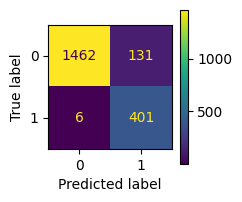

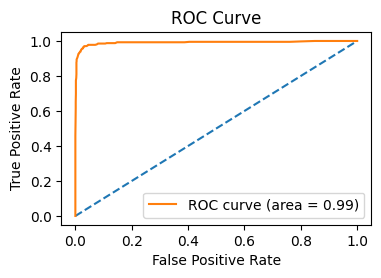

(RandomForestClassifier(random_state=123), 1.0, 0.8541001064962727)

In [207]:
test_model(forest, x, y, outliers_to_remove=OUTLIERS_TO_REMOVE_IN_TRAINING, upsample_minority=True)